# Racist Sexist or Not using Deep Learning Models

**Student Name:** Nirjala Manandhar
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio – Practical Assignment  

This project focuses on classifying tweets into Racist Sexist or Not categories using different deep learning approaches such as RNN and LSTM with word embeddings.


## 1. Install Dependencies

In [ ]:
# Install required packages
!pip install -q gensim
!pip install -q gradio
!pip install -q nltk
!pip install -q wordcloud
print('Required libraries installed successfully.')

Required libraries installed successfully.


## 2. Import Required Libraries

In [ ]:
import os
import re
import time
import random
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Ensuring reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

# NLTK
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully.


## 3. Mount Google Drive and Load Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

TRAIN_PATH = "/content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/train_racisit.csv"
TEST_PATH  = "/content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/test_racisit.csv"

print("Using train:", TRAIN_PATH)
print("Using test: ", TEST_PATH)

Using train: /content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/train_racisit.csv
Using test:  /content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/test_racisit.csv


## 4. Load and Understand the Dataset

In [ ]:
train_dataframe = pd.read_csv(TRAIN_PATH)
test_dataframe  = pd.read_csv(TEST_PATH)

print("Training dataset shape:", train_dataframe.shape)
print("Testing dataset shape: ", test_dataframe.shape)
print("\nTrain columns:", train_dataframe.columns.tolist())
print("Test columns: ", test_dataframe.columns.tolist())

print("\nTrain sample:")
display(train_dataframe.head())

print("Missing values in train:")
print(train_dataframe.isnull().sum())

Training dataset shape: (31962, 3)
Testing dataset shape:  (17197, 2)

Train columns: ['id', 'label', 'tweet']
Test columns:  ['id', 'tweet']

Train sample:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Missing values in train:
id       0
label    0
tweet    0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class balance: 29720  (93.0%) | 2242 Racist Sexist (7.0%)


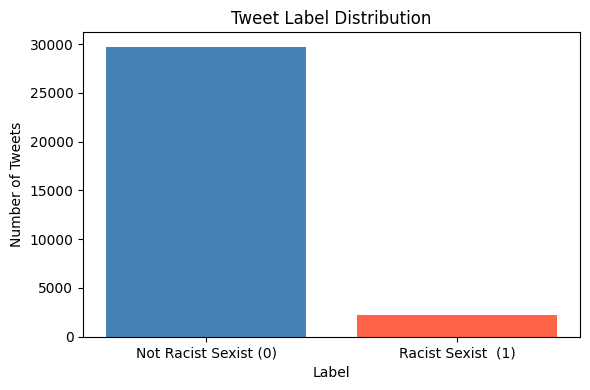


Tweet word length statistics:


,tweet_length
count,31962.00000
mean,13.15872
std,5.47815
min,3.00000
25%,9.00000
50%,13.00000
75%,17.00000
max,34.00000


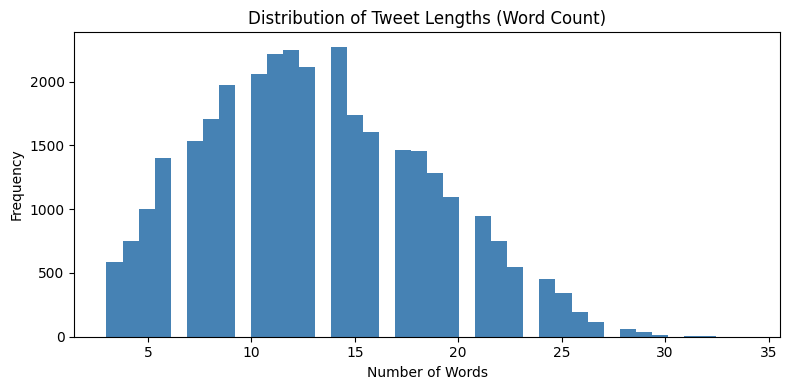

In [ ]:
# Label distribution
label_counts = train_dataframe["label"].value_counts().sort_index()
print("Label distribution:")
print(label_counts)
print(f"\nClass balance: {label_counts[0]}  ({label_counts[0]/len(train_dataframe)*100:.1f}%) | "
      f"{label_counts[1]} Racist Sexist ({label_counts[1]/len(train_dataframe)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(["Not Racist Sexist (0)", "Racist Sexist  (1)"], label_counts.values, color=["steelblue", "tomato"])
plt.title("Tweet Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

# Tweet length distribution
train_dataframe["tweet_length"] = train_dataframe["tweet"].apply(lambda x: len(str(x).split()))

print("\nTweet word length statistics:")
display(train_dataframe["tweet_length"].describe())

plt.figure(figsize=(8, 4))
plt.hist(train_dataframe["tweet_length"], bins=40, color="steelblue")
plt.title("Distribution of Tweet Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

Steps performed:
- Lowercase conversion
- Expand contractions
- Remove URLs
- Remove mentions (@user) and hashtags (#)
- Remove numbers and special characters
- Remove stopwords
- Lemmatization

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Contraction dictionary
contractions_dict = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "what's": "what is", "you're": "you are", "you've": "you have",
    "we're": "we are", "they're": "they are", "he's": "he is", "she's": "she is",
    "i'd": "i would", "we'd": "we would", "they'd": "they would",
    "let's": "let us", "who's": "who is", "how's": "how is"
}

def expand_contractions(text):
    text = str(text).lower()
    for contraction, expanded in contractions_dict.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", expanded, text)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters, keep alphabets and spaces only
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

start_time = time.time()
train_dataframe["cleaned_text"] = train_dataframe["tweet"].apply(clean_text)
print(f"Text cleaning completed in {time.time() - start_time:.2f} seconds.")

# Show before/after
print("\nBefore and after cleaning:")
display(train_dataframe[["tweet", "cleaned_text", "label"]].head(5))

Text cleaning completed in 9.46 seconds.

Before and after cleaning:


,tweet,cleaned_text,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunction,0
1,@user @user thanks for #lyft credit i can't us...,thanks credit cannot use cause offer wheelchai...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,love take time,0
4,factsguide: society now #motivation,factsguide society,0


## 7. Visualize Cleaned Text

Top 20 most frequent words:


,word,count
0,day,2596
1,amp,1777
2,happy,1588
3,love,1264
4,time,1210
5,today,1029
6,like,1006
7,get,994
8,new,930
9,one,836


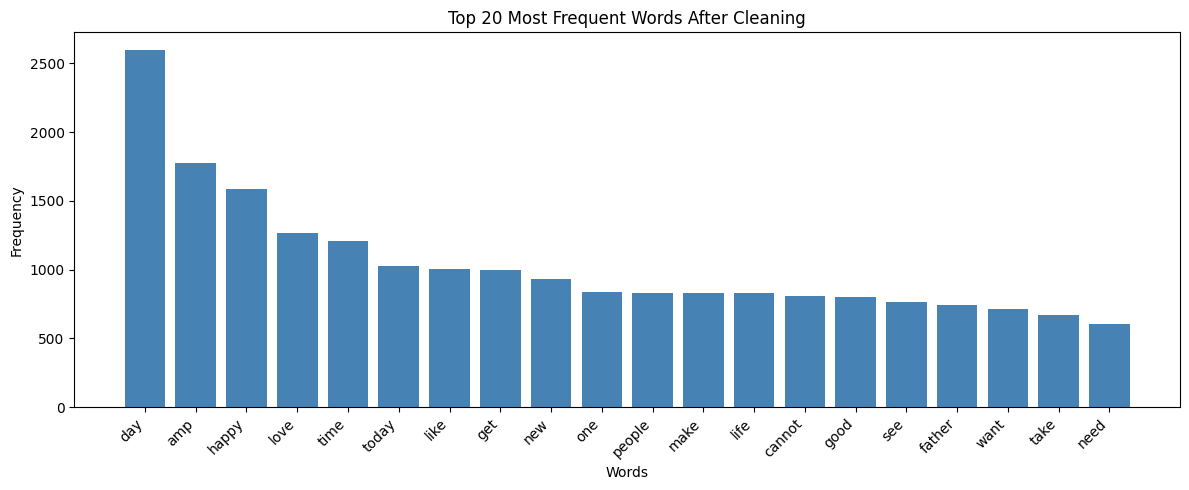

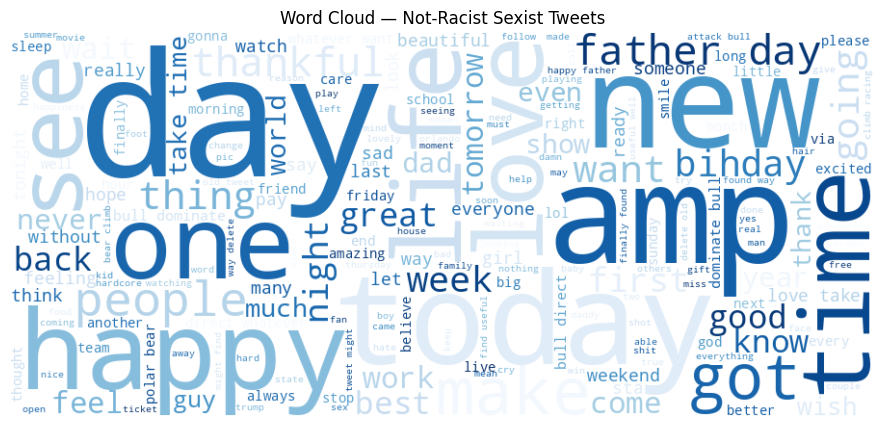

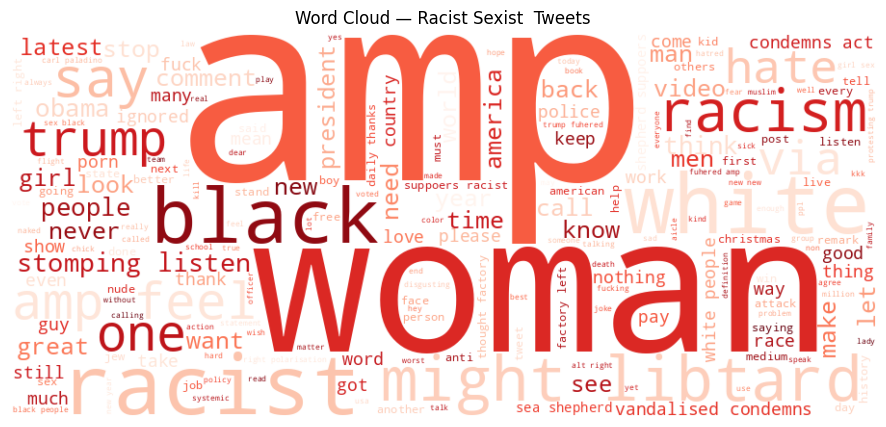

In [ ]:
from collections import Counter

# Top 20 most frequent words
all_words = " ".join(train_dataframe["cleaned_text"]).split()
word_counts = Counter(all_words)
most_common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

print("Top 20 most frequent words:")
display(most_common_words)

plt.figure(figsize=(12, 5))
plt.bar(most_common_words["word"], most_common_words["count"], color="steelblue")
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Word clouds for each class
try:
    from wordcloud import WordCloud

    for label, color, title in [(0, "Blues", "Not-Racist Sexist Tweets"), (1, "Reds", "Racist Sexist  Tweets")]:
        subset = train_dataframe[train_dataframe["label"] == label]["cleaned_text"]
        text_for_cloud = " ".join(subset.sample(min(2000, len(subset)), random_state=SEED))
        wc = WordCloud(width=900, height=400, background_color="white", colormap=color).generate(text_for_cloud)

        plt.figure(figsize=(12, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud — {title}")
        plt.show()

except Exception as e:
    print("WordCloud could not be generated:", e)

## 8. Prepare Labels and Train/Test Split

As per assignment guidelines: **80% training, 20% testing**.  
A validation set of 20% is carved out from the training set for model tuning.

In [ ]:
# Remove rows with empty cleaned text
df_model = train_dataframe[train_dataframe["cleaned_text"].str.len() > 0].copy()

X = df_model["cleaned_text"].values
y = df_model["label"].values

# Assignment guideline: 80% train, 20% test — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Further split training set: 80% train, 20% validation (of the training portion)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print(f"  Training samples  : {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")
print(f"  Test samples      : {len(X_test)}")

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

  Training samples  : 20064
  Validation samples: 5016
  Test samples      : 6271

Training label distribution:
0    18637
1     1427
Name: count, dtype: int64

Test label distribution:
0    5825
1     446
Name: count, dtype: int64


## 9. Tokenization and Percentile-Based Padding

In [ ]:
MAX_NUM_WORDS = 20000
OOV_TOKEN = "<OOV>"

# Fit tokenizer only on training data
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding to avoid excessively long sequences
train_lengths = [len(seq) for seq in X_train_seq]
percentile_len = int(np.percentile(train_lengths, 95))
MAX_SEQUENCE_LENGTH = min(max(percentile_len, 20), 100)

print(f"95th percentile sequence length : {percentile_len}")
print(f"Final MAX_SEQUENCE_LENGTH        : {MAX_SEQUENCE_LENGTH}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

vocab_size  = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)
num_classes = 1  # Binary classification → sigmoid output

print(f"Vocabulary size     : {vocab_size}")
print(f"X_train_pad shape   : {X_train_pad.shape}")
print(f"X_val_pad shape     : {X_val_pad.shape}")
print(f"X_test_pad shape    : {X_test_pad.shape}")

95th percentile sequence length : 11
Final MAX_SEQUENCE_LENGTH        : 20
Vocabulary size     : 14750
X_train_pad shape   : (20064, 20)
X_val_pad shape     : (5016, 20)
X_test_pad shape    : (6271, 20)


## 10. Helper Functions for Training and Evaluation

In [ ]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, title):
    labels = ["Not Racist Sexist (0)", "Racist Sexist  (1)"]
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=30, ha="right")
    plt.yticks(tick_marks, labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_data, y_true, model_name, threshold=0.5):
    y_prob = model.predict(X_data, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    print("\n" + "=" * 60)
    print(f"{model_name} — Test Evaluation")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Racist Sexist (0)", "Racist Sexist  (1)"],
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, f"{model_name} — Confusion Matrix")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }, y_pred, y_prob

EPOCHS       = 10
BATCH_SIZE   = 64
EMBEDDING_DIM = 64

print("Helper functions ready.")

Helper functions ready.


## 11. Model 1 — Simple RNN with Trainable Embedding

In [ ]:
def build_simple_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Force build so summary shows correct params
    model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 20, 64)         │       944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,481 (3.65 MB)

 Trainable params: 956,481 (3.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Rebuild model fresh before retraining
rnn_model = build_simple_rnn_model()

print("\nTraining Simple RNN model...")
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

rnn_time = time.time() - start_time
print(f"Simple RNN training time: {rnn_time:.2f} seconds")

Class weights: {0: np.float64(0.5382840585931212), 1: np.float64(7.030133146461107)}

Training Simple RNN model...
Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6790 - loss: 0.5851 - val_accuracy: 0.8359 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9054 - loss: 0.2536 - val_accuracy: 0.6362 - val_loss: 0.7841 - learning_rate: 0.0010
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9562 - loss: 0.1273 - val_accuracy: 0.8589 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0733 - val_accuracy: 0.8692 - val_loss: 0.4176 - learning_rate: 5.0000e-04
Simple RNN training time: 16.40 seconds


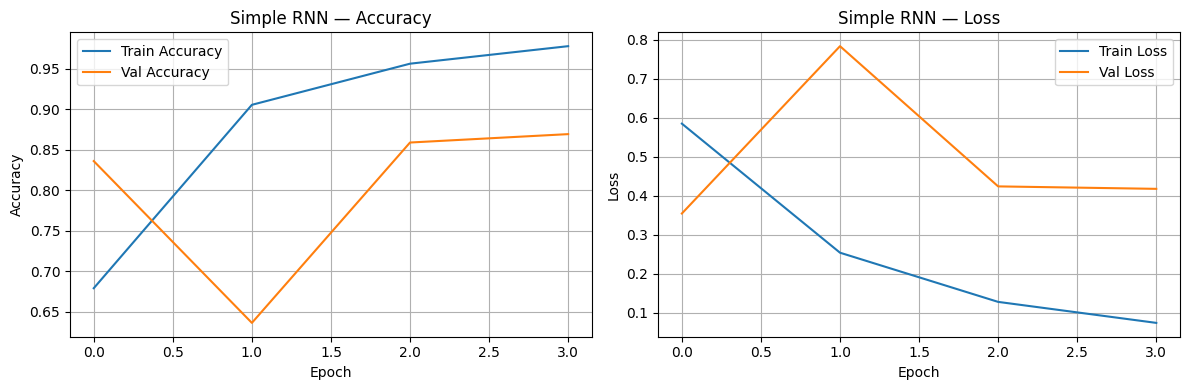


Simple RNN — Test Evaluation
Accuracy : 0.8361
Precision: 0.2630
Recall   : 0.7242
F1-score : 0.3859

Classification Report:
                       precision    recall  f1-score   support

Not Racist Sexist (0)       0.98      0.84      0.91      5825
   Racist Sexist  (1)       0.26      0.72      0.39       446

             accuracy                           0.84      6271
            macro avg       0.62      0.78      0.65      6271
         weighted avg       0.92      0.84      0.87      6271



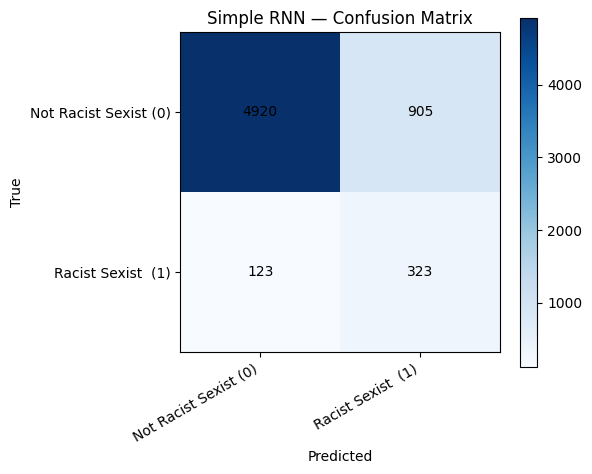

In [ ]:
plot_history(history_rnn, "Simple RNN")
rnn_results, rnn_pred, rnn_prob = evaluate_model(rnn_model, X_test_pad, y_test, "Simple RNN")

## 12. Model 2 — LSTM with Trainable Embedding

In [ ]:
def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),
        LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 20, 64)         │       944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,249 (3.74 MB)

 Trainable params: 981,249 (3.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Rebuild fresh model
lstm_model = build_lstm_model()

print("Training LSTM model...")
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")

Training LSTM model...
Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.5111 - loss: 0.6936 - val_accuracy: 0.9288 - val_loss: 0.6196 - learning_rate: 0.0010
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8051 - loss: 0.5201 - val_accuracy: 0.9354 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.9012 - loss: 0.3567 - val_accuracy: 0.9352 - val_loss: 0.2141 - learning_rate: 0.0010
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9378 - loss: 0.2525 - val_accuracy: 0.9153 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9499 - loss: 0.1942 - val_accuracy: 0.9193 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9610 - loss: 0.1519 - val_accuracy: 0.9049 - val_loss: 0.3083 - learning_rate: 5.0000e-04
LSTM training time: 182.12 seconds


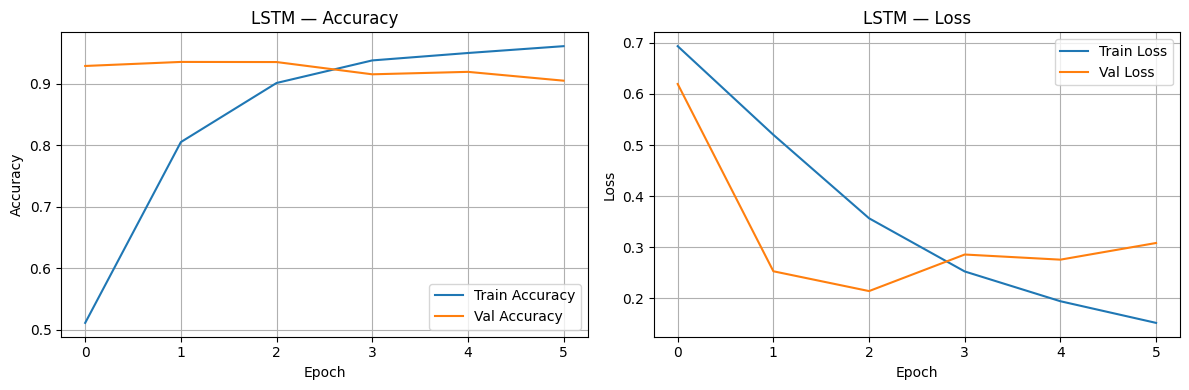


LSTM — Test Evaluation
Accuracy : 0.9322
Precision: 0.5228
Recall   : 0.5404
F1-score : 0.5314

Classification Report:
                       precision    recall  f1-score   support

Not Racist Sexist (0)       0.96      0.96      0.96      5825
   Racist Sexist  (1)       0.52      0.54      0.53       446

             accuracy                           0.93      6271
            macro avg       0.74      0.75      0.75      6271
         weighted avg       0.93      0.93      0.93      6271



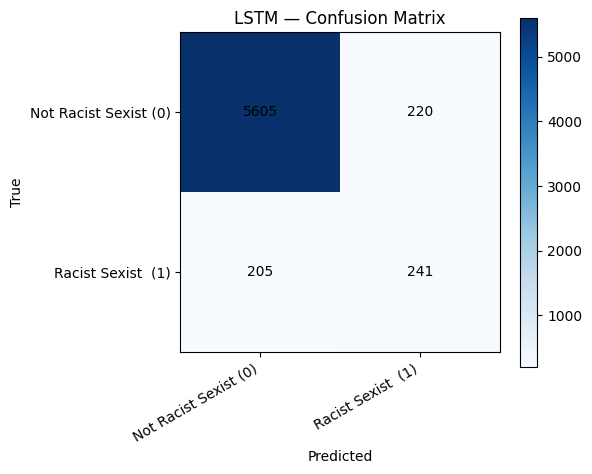

In [ ]:
plot_history(history_lstm, "LSTM")
lstm_results, lstm_pred, lstm_prob = evaluate_model(lstm_model, X_test_pad, y_test, "LSTM")

## 13. Model 3 — LSTM with Pre-trained Word2Vec Embeddings (via gensim)


In [ ]:
import gensim.downloader as api

PRETRAINED_DIM = 100
PRETRAINED_AVAILABLE = False
embedding_model = None

try:
    print("Loading pre-trained Word2Vec/GloVe embeddings: glove-wiki-gigaword-100")
    print("This may take a few minutes on first run...")
    embedding_model = api.load("glove-wiki-gigaword-100")
    PRETRAINED_AVAILABLE = True
    print("Pre-trained embeddings loaded successfully.")
except Exception as e:
    print("Could not load glove-wiki-gigaword-100. Trying glove-twitter-25 as fallback...")
    try:
        embedding_model = api.load("glove-twitter-25")
        PRETRAINED_DIM = 25
        PRETRAINED_AVAILABLE = True
        print("Fallback embeddings (glove-twitter-25) loaded successfully.")
    except Exception as e2:
        print("Could not load any pre-trained embeddings. Will use random init.")
        print("Reason:", e2)

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, PRETRAINED_DIM))

if PRETRAINED_AVAILABLE:
    found_words = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found_words += 1

    print(f"\nWords found in pre-trained model : {found_words}")
    print(f"Vocabulary coverage              : {round(found_words / vocab_size * 100, 2)}%")
else:
    np.random.seed(SEED)
    embedding_matrix = np.random.normal(0, 0.05, size=(vocab_size, PRETRAINED_DIM))
    embedding_matrix[0] = np.zeros(PRETRAINED_DIM)
    print("Using randomly initialized embedding matrix as fallback.")

print("Embedding matrix shape:", embedding_matrix.shape)

Loading pre-trained Word2Vec/GloVe embeddings: glove-wiki-gigaword-100
This may take a few minutes on first run...
Pre-trained embeddings loaded successfully.

Words found in pre-trained model : 12464
Vocabulary coverage              : 84.5%
Embedding matrix shape: (14750, 100)


In [ ]:
def build_pretrained_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            trainable=False  # Freeze pre-trained weights
        ),
        LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
    return model

pretrained_lstm_model = build_pretrained_lstm_model()
pretrained_lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 20, 100)        │     1,475,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,521,465 (5.80 MB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 1,475,000 (5.63 MB)

In [ ]:

pretrained_lstm_model = build_pretrained_lstm_model()

print("Training LSTM with pre-trained Word2Vec embeddings...")
start_time = time.time()

history_pretrained = pretrained_lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

pretrained_time = time.time() - start_time
print(f"Pre-trained LSTM training time: {pretrained_time:.2f} seconds")

Training LSTM with pre-trained Word2Vec embeddings...
Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.6972 - loss: 0.5864 - val_accuracy: 0.8285 - val_loss: 0.3981 - learning_rate: 0.0010
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7732 - loss: 0.5291 - val_accuracy: 0.8419 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.7814 - loss: 0.5068 - val_accuracy: 0.8335 - val_loss: 0.4071 - learning_rate: 0.0010
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.7840 - loss: 0.4949 - val_accuracy: 0.8591 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.7723 - loss: 0.4814 - val_accuracy: 0.8758 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7850 - loss: 0.4696 - val_accuracy: 0.8696 - val_loss: 0.3172 - learning_rate: 0.0010
Epoch 7/10
314/314 ━━━

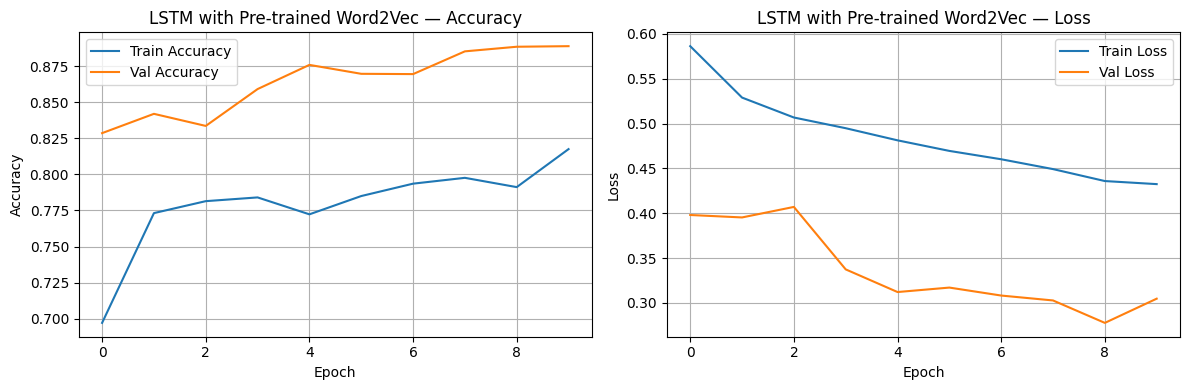


LSTM with Pre-trained Word2Vec — Test Evaluation
Accuracy : 0.8861
Precision: 0.3498
Recall   : 0.6996
F1-score : 0.4664

Classification Report:
                       precision    recall  f1-score   support

Not Racist Sexist (0)       0.98      0.90      0.94      5825
   Racist Sexist  (1)       0.35      0.70      0.47       446

             accuracy                           0.89      6271
            macro avg       0.66      0.80      0.70      6271
         weighted avg       0.93      0.89      0.90      6271



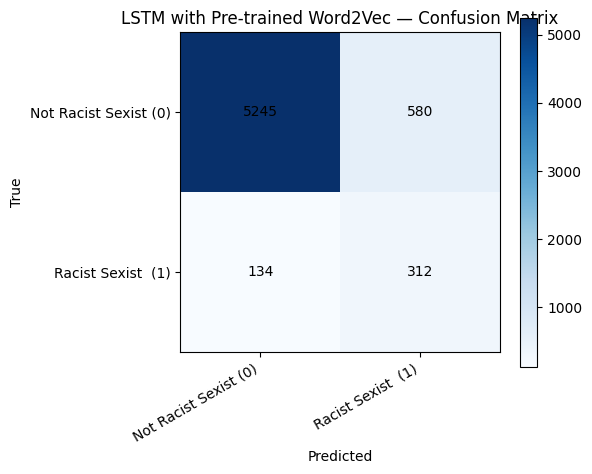

In [ ]:
plot_history(history_pretrained, "LSTM with Pre-trained Word2Vec")
pretrained_results, pretrained_pred, pretrained_prob = evaluate_model(
    pretrained_lstm_model, X_test_pad, y_test, "LSTM with Pre-trained Word2Vec"
)

## 14. Final Model Comparison


Final Model Comparison:


,model,accuracy,precision,recall,f1_score,training_time_sec
0,LSTM,0.932228,0.522777,0.540359,0.531422,182.117739
1,LSTM with Pre-trained Word2Vec,0.886143,0.349776,0.699552,0.466368,264.620421
2,Simple RNN,0.836071,0.263029,0.724215,0.385902,16.403475


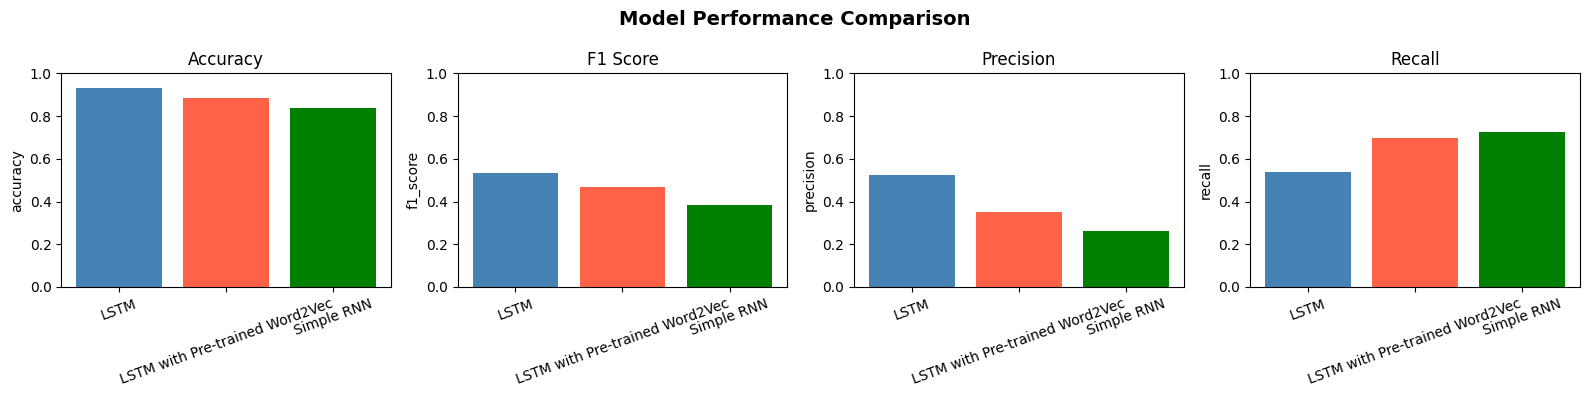

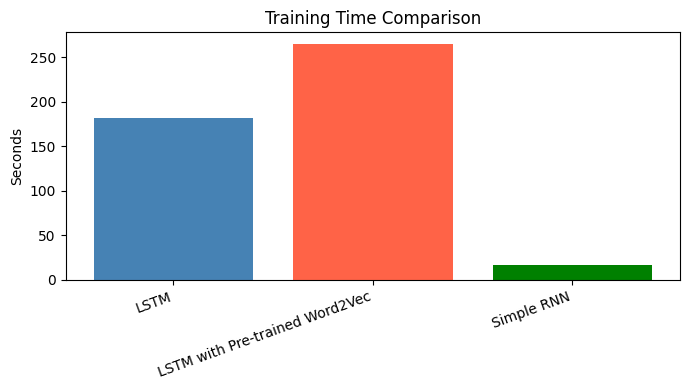

In [ ]:
results = [rnn_results, lstm_results, pretrained_results]
results_df = pd.DataFrame(results)

training_times = {
    "Simple RNN": rnn_time,
    "LSTM": lstm_time,
    "LSTM with Pre-trained Word2Vec": pretrained_time
}
results_df["training_time_sec"] = results_df["model"].map(training_times)
results_df = results_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison:")
display(results_df)

metrics = ["accuracy", "f1_score", "precision", "recall"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))

for ax, metric in zip(axes, metrics):
    ax.bar(results_df["model"], results_df[metric], color=["steelblue", "tomato", "green"])
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(results_df["model"], results_df["training_time_sec"], color=["steelblue", "tomato", "green"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Final Model Comparison:


,model,accuracy,precision,recall,f1_score,training_time_sec,short_model
0,LSTM,0.932228,0.522777,0.540359,0.531422,182.117739,LSTM
1,LSTM with Pre-trained Word2Vec,0.886143,0.349776,0.699552,0.466368,264.620421,LSTM + Word2Vec
2,Simple RNN,0.836071,0.263029,0.724215,0.385902,16.403475,Simple RNN


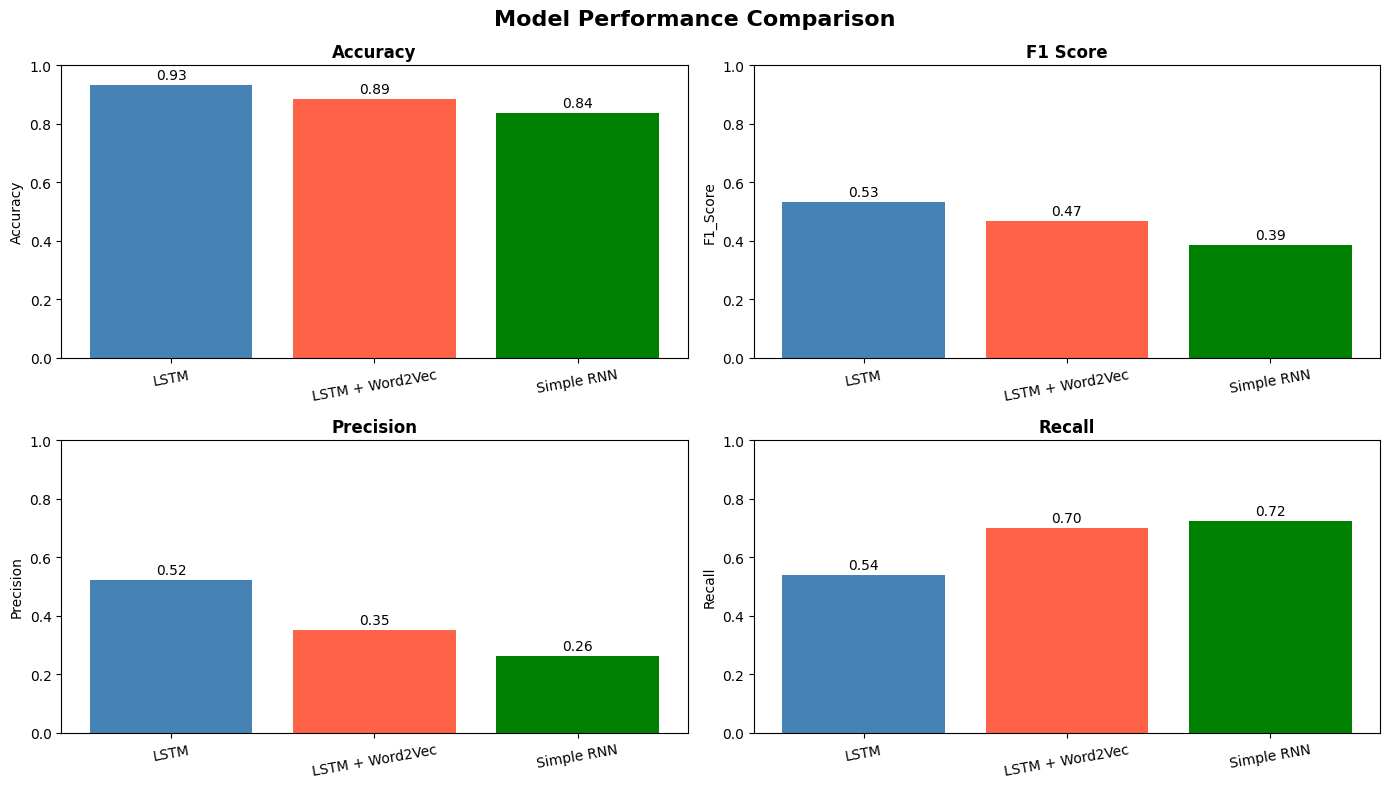

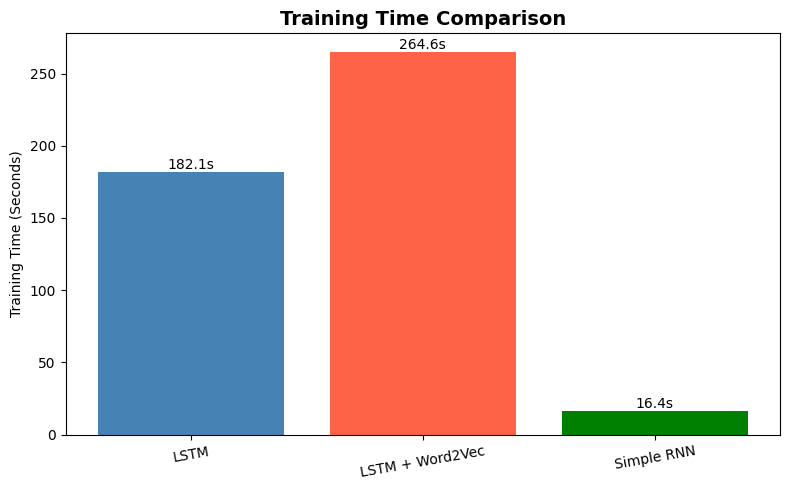

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Create Results DataFrame
# =========================

results = [rnn_results, lstm_results, pretrained_results]
results_df = pd.DataFrame(results)

# =========================
# Add Training Time
# =========================

training_times = {
    "Simple RNN": rnn_time,
    "LSTM": lstm_time,
    "LSTM with Pre-trained Word2Vec": pretrained_time
}

results_df["training_time_sec"] = results_df["model"].map(training_times)

# =========================
# Sort by F1 Score
# =========================

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
).reset_index(drop=True)

# =========================
# Short Model Names
# =========================

short_names = {
    "LSTM": "LSTM",
    "LSTM with Pre-trained Word2Vec": "LSTM + Word2Vec",
    "Simple RNN": "Simple RNN"
}

results_df["short_model"] = results_df["model"].map(short_names)

# =========================
# Display Final Table
# =========================

print("\nFinal Model Comparison:")
display(results_df)

# =========================
# Metrics Comparison Graph
# =========================

metrics = ["accuracy", "f1_score", "precision", "recall"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors = ["steelblue", "tomato", "green"]

for ax, metric in zip(axes, metrics):

    bars = ax.bar(
        results_df["short_model"],
        results_df[metric],
        color=colors
    )

    ax.set_title(
        metric.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel(metric.title())
    ax.set_ylim(0, 1)

    # Rotate labels
    ax.tick_params(axis='x', rotation=10)

    # Add value labels
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.2f}",
            ha='center',
            fontsize=10
        )

# Main title
plt.suptitle(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =========================
# Training Time Graph
# =========================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df["short_model"],
    results_df["training_time_sec"],
    color=colors
)

plt.title(
    "Training Time Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Training Time (Seconds)")
plt.xticks(rotation=10)

# Add labels on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}s",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 15. Error Analysis

Examining misclassified tweets from the best-performing model to understand failure cases.

In [ ]:
# Select best model by F1-score
best_model_name = results_df.iloc[0]["model"]
print("Best model selected for error analysis:", best_model_name)

if best_model_name == "Simple RNN":
    best_pred = rnn_pred
    best_prob = rnn_prob
    best_model = rnn_model
elif best_model_name == "LSTM":
    best_pred = lstm_pred
    best_prob = lstm_prob
    best_model = lstm_model
else:
    best_pred = pretrained_pred
    best_prob = pretrained_prob
    best_model = pretrained_lstm_model

# Build test dataframe
_, X_test_raw, _, y_test_raw = train_test_split(
    df_model["tweet"].values, df_model["label"].values,
    test_size=0.20, random_state=SEED, stratify=df_model["label"].values
)

error_df = pd.DataFrame({
    "tweet": X_test_raw,
    "true_label": y_test,
    "predicted_label": best_pred,
    "confidence": best_prob
})

misclassified = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()
misclassified = misclassified.sort_values(by="confidence", ascending=False)

print(f"Total misclassified: {len(misclassified)} out of {len(error_df)} test samples")
print(f"Error rate: {len(misclassified)/len(error_df)*100:.2f}%")

print("\nTop misclassified examples:")
display(misclassified[["tweet", "true_label", "predicted_label", "confidence"]].head(5))

print("\n--- Detailed Error Analysis (Top 3) ---")
for i, (_, row) in enumerate(misclassified.head(3).iterrows()):
    true_str = "Racist Sexist " if row["true_label"] == 1 else "Not Racist Sexist"
    pred_str = "Racist Sexist " if row["predicted_label"] == 1 else "Not Racist Sexist"
    print(f"\nExample {i+1}:")
    print(f"  Tweet     : {row['tweet'][:200]}")
    print(f"  True Label: {true_str}")
    print(f"  Predicted : {pred_str}")
    print(f"  Confidence: {row['confidence']:.3f}")

Best model selected for error analysis: LSTM
Total misclassified: 425 out of 6271 test samples
Error rate: 6.78%

Top misclassified examples:


,tweet,true_label,predicted_label,confidence
36,if you're a black woman dating a racist white ...,0,1,0.981661
6127,black or clear? black - clear - #earrings ...,0,1,0.980525
4400,so @user acknowledges the racist comments by @...,0,1,0.980085
616,@user i think you should suspend indefininetly...,0,1,0.978919
5153,@user no i mean over the course of the next de...,0,1,0.978572



--- Detailed Error Analysis (Top 3) ---

Example 1:
  Tweet     : if you're a black woman dating a racist white man it isn't your job to teach him how to not be racist and it won't work either.  
  True Label: Not Racist Sexist
  Predicted : Racist Sexist 
  Confidence: 0.982

Example 2:
  Tweet     : black or clear?  black -  clear -   #earrings   #flowers 
  True Label: Not Racist Sexist
  Predicted : Racist Sexist 
  Confidence: 0.981

Example 3:
  Tweet     : so @user acknowledges the racist comments by @user but still backs him??!! #spineless #shameful  
  True Label: Not Racist Sexist
  Predicted : Racist Sexist 
  Confidence: 0.980


### Error Analysis Discussion

Common reasons for misclassification in Racist Sexist  detection:

1. **Sarcasm and irony** — A tweet may appear positive but carry Racist Sexistful intent
2. **Context dependency** — Some words are offensive only in certain contexts
3. **Class imbalance** — The dataset has far more non-Racist Sexist tweets (~93%) than Racist Sexist tweets (~7%), making the model biased toward predicting non-Racist Sexist
4. **Subtle language** — Coded language or dog whistles that are hard to detect without cultural context
5. **Short tweets** — Very short tweets provide little context for the model to learn from

**Suggested improvements:**
- Apply class weights or oversampling (SMOTE) to handle class imbalance
- Use a Bidirectional LSTM to capture context from both directions
- Fine-tune a transformer model like BERT for better contextual understanding

## 16. Real-time Prediction Function

In [ ]:
def predict_tweet(tweet):
    # Clean the input tweet using the defined clean_text function
    cleaned_tweet = clean_text(tweet)

    # Tokenize the cleaned text
    # The tokenizer object was fitted earlier in the notebook
    seq = tokenizer.texts_to_sequences([cleaned_tweet])

    # Pad the sequence to the maximum length determined during preprocessing
    padded_seq = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

    # Predict using the best model identified during evaluation
    # The best_model variable is set in the Error Analysis section
    prediction_prob = best_model.predict(padded_seq, verbose=0)[0][0]
    prediction_label = (prediction_prob >= 0.5).astype(int)

    # Map the numerical label back to a human-readable string
    if prediction_label == 0:
        result = "Not Racist Sexist"
    else:
        result = "Racist Sexist"

    return result, prediction_prob

print("Prediction function 'predict_tweet' defined.")

Prediction function 'predict_tweet' defined.


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove mentions (@user) completely
    text = re.sub(r"@\w+", " ", text)

    # Keep hashtag words, just remove the # symbol
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters, keep alphabets and spaces only
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

start_time = time.time()
train_dataframe["cleaned_text"] = train_dataframe["tweet"].apply(clean_text)
print(f"Text cleaning completed in {time.time() - start_time:.2f} seconds.")

# Verify the fix
test_tweets = [
    "These people should go back to where they came from #racist",
    "all women are useless and belong in the kitchen",
    "I love everyone regardless of their background!"
]
print("\nVerification:")
for tweet in test_tweets:
    print(f"Original : {tweet}")
    print(f"Cleaned  : '{clean_text(tweet)}'")
    print()

# Show before/after
print("Sample cleaned data:")
display(train_dataframe[["tweet", "cleaned_text", "label"]].head(5))

Text cleaning completed in 5.99 seconds.

Verification:
Original : These people should go back to where they came from #racist
Cleaned  : 'people back came racist'

Original : all women are useless and belong in the kitchen
Cleaned  : 'woman useless belong kitchen'

Original : I love everyone regardless of their background!
Cleaned  : 'love everyone regardless background'

Sample cleaned data:


,tweet,cleaned_text,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use cause offer whee...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0


## 17. Gradio GUI for Real-Time Prediction

As required by the assignment — a real-time prediction interface using Gradio.

In [ ]:
try:
    import gradio as gr
except Exception:
    !pip -q install gradio
    import gradio as gr

def gradio_predict(tweet_text):
    if not tweet_text.strip():
        return "Please enter a tweet."
    result, confidence = predict_tweet(tweet_text)
    return f"Prediction: {result}\nConfidence Score: {confidence:.4f}"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet here...",
        label="Tweet"
    ),
    outputs=gr.Textbox(label="Prediction"),
    title="Racist Sexist  Detector",
    description="Enter a tweet to predict whether it contains racist or sexist Racist Sexist .",
    examples=[
        ["I love everyone regardless of their background!"],
        ["These people should go back where they came from"],
        ["Great game today everyone played really well"]
    ]
)

demo.launch(share=True)  # share=True gives a public URL in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1e2e38ad635f9508e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 18. Save Best Model and Tokenizer

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Racist Sexist__nlp_model"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path  = os.path.join(SAVE_DIR, "best_Racist Sexist__model.keras")
tokenizer_path   = os.path.join(SAVE_DIR, "Racist Sexist__tokenizer.pkl")
metadata_path    = os.path.join(SAVE_DIR, "metadata.txt")

best_model.save(best_model_path)

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

with open(metadata_path, "w") as f:
    f.write(f"best_model_name: {best_model_name}\n")
    f.write(f"max_sequence_length: {MAX_SEQUENCE_LENGTH}\n")
    f.write(f"vocab_size: {vocab_size}\n")
    f.write("label_mapping: 0=Not Racist Sexist, 1=Racist Sexist \n")

print("Model saved to:", best_model_path)
print("Tokenizer saved to:", tokenizer_path)

Model saved to: /content/drive/MyDrive/Racist Sexist__nlp_model/best_Racist Sexist__model.keras
Tokenizer saved to: /content/drive/MyDrive/Racist Sexist__nlp_model/Racist Sexist__tokenizer.pkl


## Conclusion
The implemented text classification models were evaluated on tweet datasets to analyze Racist Sexist  detection performance. Among the tested models, deep learning approaches showed improved classification capability.